In [2]:
import kagglehub
from pathlib import Path 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


/Users/gabrieltedja/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Download latest version
na_folder = Path(kagglehub.dataset_download("jasonairroi/airbnb-market-data-north-america"))
eu_folder = Path(kagglehub.dataset_download("jasonairroi/airbnb-market-data-europe"))
asia_pacific_folder = Path(kagglehub.dataset_download("jasonairroi/airbnb-market-data-asia-pacific"))
latin_caribbean_folder = Path(kagglehub.dataset_download("jasonairroi/airbnb-market-data-latin-america-caribbean"))

na_listings_path = na_folder / "listings.csv"
eu_listings_path = eu_folder / "listings.csv"
asia_pacific_listings_path = asia_pacific_folder / "listings.csv"
latin_caribbean_listings_path = latin_caribbean_folder / "listings.csv"

na_past_rates_path = na_folder / "past_rates.csv"
eu_past_rates_path = eu_folder / "past_rates.csv"
asia_pacific_past_rates_path = asia_pacific_folder / "past_rates.csv"
latin_caribbean_past_rates_path = latin_caribbean_folder / "past_rates.csv"

In [4]:
import pandas as pd
import numpy as np


na_listings = pd.read_csv(na_listings_path, sep=None, engine="python", on_bad_lines="skip")
eu_listings = pd.read_csv(eu_listings_path, sep=None, engine="python", on_bad_lines="skip")
asia_pacific_listings = pd.read_csv(asia_pacific_listings_path, sep=None, engine="python", on_bad_lines="skip")
latin_caribbean_listings = pd.read_csv(latin_caribbean_listings_path, sep=None, engine="python", on_bad_lines="skip")

na_past_rates = pd.read_csv(na_past_rates_path, sep=None, engine="python", on_bad_lines="skip")
eu_past_rates = pd.read_csv(eu_past_rates_path, sep=None, engine="python", on_bad_lines="skip")
asia_pacific_past_rates = pd.read_csv(asia_pacific_past_rates_path, sep=None, engine="python", on_bad_lines="skip")
latin_caribbean_past_rates = pd.read_csv(latin_caribbean_past_rates_path, sep=None, engine="python", on_bad_lines="skip")

na_listings["Region"] = "North America"
eu_listings["Region"] = "Europe"
asia_pacific_listings["Region"] = "Asia-Pacific"
latin_caribbean_listings["Region"] = "Latin America/Caribbean"

na_past_rates["Region"] = "North America"
eu_past_rates["Region"] = "Europe"
asia_pacific_past_rates["Region"] = "Asia-Pacific"
latin_caribbean_past_rates["Region"] = "Latin America/Caribbean"

all_listings = pd.concat([na_listings, eu_listings, asia_pacific_listings, latin_caribbean_listings], ignore_index=True)
all_past_rates = pd.concat([na_past_rates, eu_past_rates, asia_pacific_past_rates, latin_caribbean_past_rates], ignore_index=True)

In [5]:
all_listings.head()

,listing_id,listing_type,room_type,cover_photo_url,photos_count,host_id,superhost,latitude,longitude,guests,...,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,country,state,city,Region
0,177833,Entire guesthouse,entire_home,https://a0.muscache.com/im/pictures/67280846-0...,36.0,c40416107927,True,38.9043,-104.973,3.0,...,0.0,0.0,8.0,0.0,82.0,90.0,United States,Colorado,Colorado Springs,North America
1,312996,Entire guesthouse,entire_home,https://a0.muscache.com/im/pictures/hosting/Ho...,34.0,62fb4136b324,True,38.8388,-104.814,2.0,...,49.5,49.5,35.0,14.0,55.0,90.0,United States,Colorado,Colorado Springs,North America
2,2237908,Entire rental unit,entire_home,https://a0.muscache.com/im/pictures/0e03770a-3...,15.0,13c8856ce8b1,True,38.8413,-104.8097,5.0,...,0.0,0.0,48.0,0.0,42.0,90.0,United States,Colorado,Colorado Springs,North America
3,2306147,Entire home,entire_home,https://a0.muscache.com/im/pictures/miso/Hosti...,16.0,8fe96865f520,True,38.8456,-104.7298,7.0,...,0.0,0.0,34.0,0.0,56.0,90.0,United States,Colorado,Colorado Springs,North America
4,2526116,Entire home,entire_home,https://a0.muscache.com/im/pictures/hosting/Ho...,39.0,d127f1078650,True,38.8368,-104.8437,8.0,...,0.0,0.0,40.0,0.0,50.0,90.0,United States,Colorado,Colorado Springs,North America


In [6]:
all_past_rates.head()

,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,booked_rate_avg,booking_lead_time_avg,length_of_stay_avg,min_nights_avg,native_booked_rate_avg,native_rate_avg,native_revenue,country,state,city,Region
0,13117492,2025-02-01,4,24,0.857,1283.0,53.4,53.5,3.0,6.0,2.0,27022.0,26972.0,648031.0,Costa Rica,Limón Province,Cahuita,North America
1,13117492,2025-03-01,15,16,0.516,874.0,54.4,54.6,18.0,3.0,2.0,27693.0,27591.0,443283.0,Costa Rica,Limón Province,Cahuita,North America
2,13117492,2025-04-01,9,21,0.700,1125.0,53.6,53.6,38.0,7.0,2.0,26822.0,26822.0,562972.0,Costa Rica,Limón Province,Cahuita,North America
3,13117492,2025-05-01,31,0,0.000,0.0,52.2,NaN,NaN,NaN,1.0,NaN,26446.0,0.0,Costa Rica,Limón Province,Cahuita,North America
4,13117492,2025-06-01,30,0,0.000,0.0,60.3,NaN,NaN,NaN,1.0,NaN,30576.0,0.0,Costa Rica,Limón Province,Cahuita,North America


In [7]:
def changetoTF(x):
    if (x == 'true' or x == True):
        return 1.0
    elif (x == 'false' or x == False):
        return 0.0
    else:
        return np.nan

In [8]:
all_listings['professional_management'].unique()

array([False, nan, True, 'false', 'true', 'Drying rack for clothing'],
      dtype=object)

In [9]:
all_listings['ttm_revenue'] = pd.to_numeric(all_listings['ttm_revenue'], errors='coerce')
all_listings['ttm_occupancy'] = pd.to_numeric(all_listings['ttm_occupancy'], errors='coerce')
all_listings['rating_overall'] = pd.to_numeric(all_listings['rating_overall'], errors='coerce')
all_listings.dropna(subset=['ttm_revenue', 'ttm_occupancy', 'rating_overall'], inplace=True)
for col in ['superhost', 'instant_book', 'professional_management']:
    all_listings[col] = all_listings[col].apply(changetoTF)

In [10]:
all_listings.columns

Index(['listing_id', 'listing_type', 'room_type', 'cover_photo_url',
       'photos_count', 'host_id', 'superhost', 'latitude', 'longitude',
       'guests', 'bedrooms', 'beds', 'baths', 'registration', 'amenities',
       'instant_book', 'professional_management', 'min_nights',
       'cancellation_policy', 'currency', 'cleaning_fee', 'extra_guest_fee',
       'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin',
       'rating_cleanliness', 'rating_communication', 'rating_location',
       'rating_value', 'ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate',
       'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy',
       'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar',
       'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_blocked_days',
       'ttm_available_days', 'ttm_total_days', 'l90d_revenue',
       'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native',
       'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar',
 

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

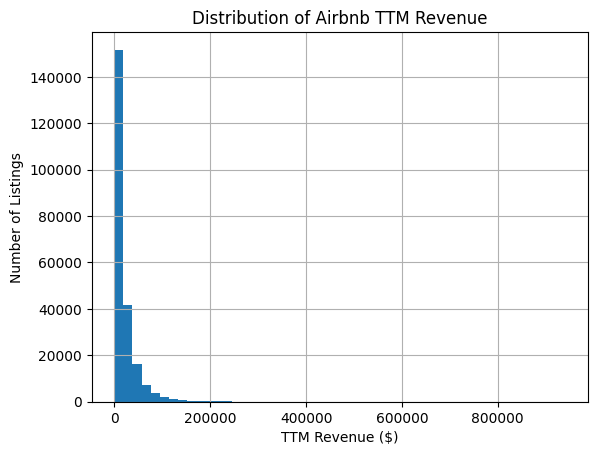

In [12]:
all_listings['ttm_revenue'].hist(bins=50)
plt.title("Distribution of Airbnb TTM Revenue")
plt.xlabel("TTM Revenue ($)")
plt.ylabel("Number of Listings")
plt.savefig("revenue_histogram.png", dpi=300, bbox_inches="tight")
plt.show()


In [13]:
all_listings.groupby('superhost')[['ttm_revenue','ttm_occupancy','rating_overall']].mean()

,ttm_revenue,ttm_occupancy,rating_overall
superhost,,,
0.0,15128.685547,0.230131,4.717700
1.0,25459.381153,0.386355,4.850788


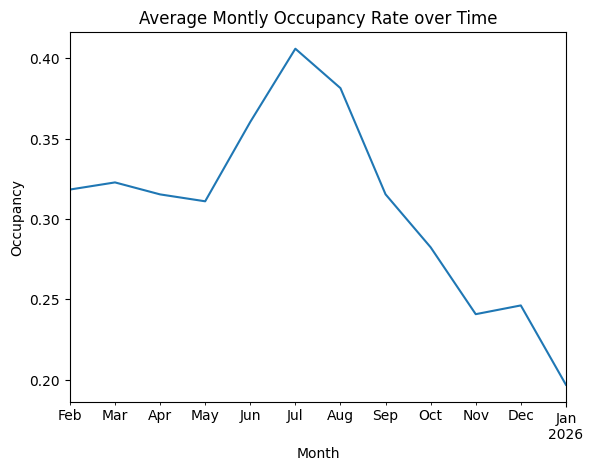

In [14]:
all_past_rates['date'] = pd.to_datetime(all_past_rates['date'])
monthly = all_past_rates.groupby(all_past_rates['date'].dt.to_period('M'))['occupancy'].mean()
monthly.plot()
plt.title("Average Montly Occupancy Rate over Time")
plt.xlabel("Month")
plt.ylabel("Occupancy")
plt.savefig("monthly_occupancy_trend.png", dpi=300, bbox_inches="tight")
plt.show()

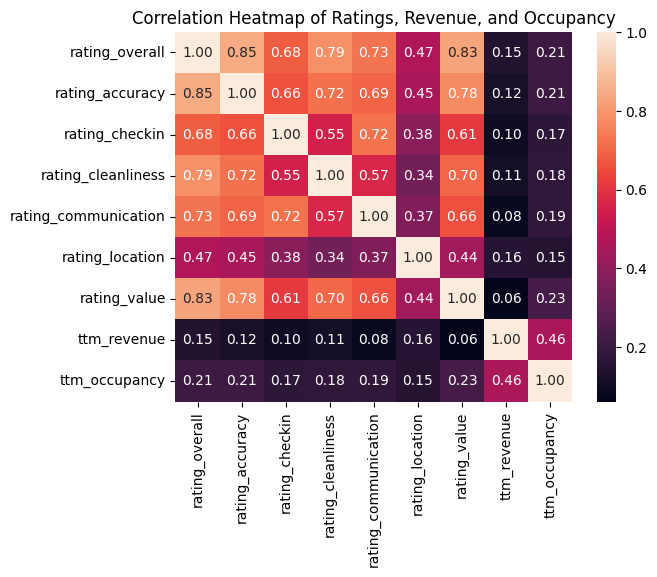

In [15]:
rating_cols = [c for c in all_listings.columns if 'rating_' in c] + ['ttm_revenue', 'ttm_occupancy']
plt.title("Correlation Heatmap of Ratings, Revenue, and Occupancy")
sns.heatmap(all_listings[rating_cols].corr(), annot=True, fmt='.2f')
plt.savefig("ratings_heatmap.png", dpi=300, bbox_inches="tight")


In [59]:
all_listings.groupby('Region')[['ttm_revenue','ttm_occupancy','rating_overall']].mean()

,ttm_revenue,ttm_occupancy,rating_overall
Region,,,
Asia-Pacific,13357.123917,0.292172,4.759683
Europe,19017.888914,0.319556,4.766966
Latin America/Caribbean,9068.212265,0.249312,4.809365
North America,30869.988417,0.332559,4.804651


From this you can infer airbnbs are more popular in North America, as opposed to other regions where people may prefer hotels.

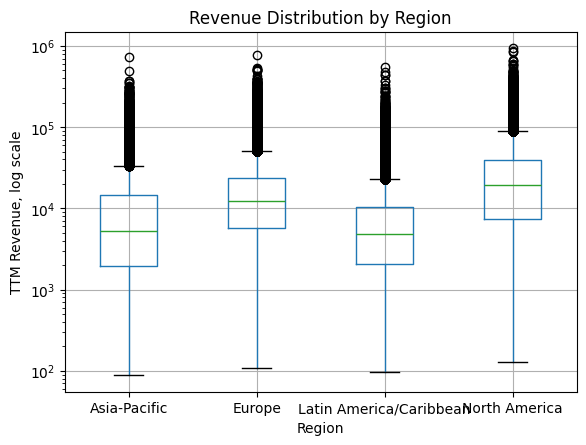

: 

In [ ]:
all_listings.boxplot(column="ttm_revenue", by="Region")
plt.yscale("log")
plt.title("Revenue Distribution by Region")
plt.suptitle("")
plt.ylabel("TTM Revenue, log scale")
plt.savefig("revenue_distribution_by_region", dpi=300, bbox_inches="tight")
plt.show()

In [61]:
all_listings["city"].value_counts().head(20)

city
Naples                581
Birmingham            507
Cartagena             505
La Paz                500
London                492
Richmond              466
Oxford                407
Arlington             375
San Jose              300
Cincinnati            300
St. Louis             300
Lisbon                300
Liverpool             300
Athens                300
Venice                300
South Padre Island    299
León                  299
Seattle               299
Oklahoma City         299
Chicago               299
Name: count, dtype: int64

In [62]:
na_cities = all_listings[all_listings["Region"] == "North America"]["city"].value_counts().head(20)
na_cities

city
Richmond              466
Arlington             375
San Jose              300
Cincinnati            300
St. Louis             300
South Padre Island    299
León                  299
Seattle               299
Oklahoma City         299
Chicago               299
Pittsburgh            299
Monterrey             299
Charlotte             299
San Francisco         299
Boston                299
Antigua Guatemala     299
Los Angeles           298
Breckenridge          298
San Diego             298
El Paso               298
Name: count, dtype: int64

In [63]:
eu_cities = all_listings[all_listings["Region"] == "Europe"]["city"].value_counts().head(20)
eu_cities

city
Lisbon                         300
Liverpool                      300
Athens                         300
Venice                         300
Chamonix-Mont-Blanc            299
Rome                           299
London                         299
Lille                          299
Barcelona                      299
City of Zagreb                 299
Valencia                       299
Lagos                          299
Annecy                         299
Bristol                        299
Leipzig                        298
Budapest                       298
Florence                       298
Wrocław                        298
Thessaloniki Municipal Unit    298
Verona                         298
Name: count, dtype: int64

In [64]:
asia_pacific_cities = all_listings[all_listings["Region"] == "Asia-Pacific"]["city"].value_counts().head(20)
asia_pacific_cities

city
Tokyo                        299
Sydney                       297
Kyoto                        297
Greater Brisbane             297
Taipei                       297
Adelaide                     296
Waitematā                    296
Bangkok                      296
Gold Coast City              295
Osaka                        295
Melbourne                    294
Ipoh                         294
Special Region of Jakarta    293
Johor Bahru                  293
Christchurch                 293
Makati                       293
George Town                  293
Tagaytay                     293
Patong                       292
Chiang Mai                   292
Name: count, dtype: int64

In [65]:
latin_caribbean_cities = all_listings[all_listings["Region"] == "Latin America/Caribbean"]["city"].value_counts().head(20)
latin_caribbean_cities

city
Goiânia                       299
Plano Piloto                  299
Rio de Janeiro                298
Medellín                      297
Santiago de los Caballeros    297
Cuenca                        297
São Sebastião                 296
Paraty                        296
Curitiba                      296
São Paulo                     296
Distrito de Cusco             296
Havana                        295
Lima Metropolitan Area        295
Maceió                        295
Cartagena                     295
Florianópolis                 295
Ilhabela                      295
Santiago                      295
Las Condes                    295
Campos do Jordão              295
Name: count, dtype: int64

In [66]:
all_listings[all_listings["city"] == "Naples"][["city", "Region"]].value_counts()


city    Region       
Naples  Europe           291
        North America    290
Name: count, dtype: int64

In [67]:
all_listings[all_listings["city"] == "La Paz"][["city", "Region"]].value_counts()

city    Region                 
La Paz  North America              296
        Latin America/Caribbean    204
Name: count, dtype: int64

In [68]:
all_listings[all_listings["city"] == "Cartagena"][["city", "Region"]].value_counts()

city       Region                 
Cartagena  Latin America/Caribbean    295
           Europe                     210
Name: count, dtype: int64

Above cells are intended to check for cities with the same name.

In [69]:
all_listings.columns

Index(['listing_id', 'listing_type', 'room_type', 'cover_photo_url',
       'photos_count', 'host_id', 'superhost', 'latitude', 'longitude',
       'guests', 'bedrooms', 'beds', 'baths', 'registration', 'amenities',
       'instant_book', 'professional_management', 'min_nights',
       'cancellation_policy', 'currency', 'cleaning_fee', 'extra_guest_fee',
       'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin',
       'rating_cleanliness', 'rating_communication', 'rating_location',
       'rating_value', 'ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate',
       'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy',
       'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar',
       'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_blocked_days',
       'ttm_available_days', 'ttm_total_days', 'l90d_revenue',
       'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native',
       'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar',
 

Some other cleaning here to make sure all numeric variables are numeric.

In [70]:


columns = ["listing_type", "room_type", "photos_count", "superhost", "latitude", "longitude", "guests",
            "bedrooms", "beds", "baths", "professional_management", "min_nights", "cancellation_policy",
            "cleaning_fee", "extra_guest_fee", "num_reviews", "rating_overall", "rating_accuracy",
            "rating_checkin", "rating_cleanliness", "rating_communication", "rating_location"
            ,"rating_value", "country", "state", "city", "Region"]

numeric_columns = ["photos_count", "latitude", "longitude", "guests", "bedrooms", "beds", "baths", "min_nights", "cleaning_fee", "extra_guest_fee", "num_reviews", "rating_overall", "rating_accuracy",
            "rating_checkin", "rating_cleanliness", "rating_communication", "rating_location"
            ,"rating_value"]

categorical_columns = ["listing_type", "room_type", "superhost", "amenities", "professional_management", "cancellation_policy",
                        "country", "state", "city", "Region"]

all_listings[numeric_columns] = all_listings[numeric_columns].apply(pd.to_numeric, errors="coerce")
all_listings[numeric_columns].dtypes

photos_count            float64
latitude                float64
longitude               float64
guests                  float64
bedrooms                float64
beds                    float64
baths                   float64
min_nights              float64
cleaning_fee            float64
extra_guest_fee         float64
num_reviews             float64
rating_overall          float64
rating_accuracy         float64
rating_checkin          float64
rating_cleanliness      float64
rating_communication    float64
rating_location         float64
rating_value            float64
dtype: object

In [71]:
all_listings.isna().sum()[all_listings.isna().sum() > 0].sort_values(ascending=False)

instant_book               191667
bedrooms                    37531
guests                      25118
professional_management     19739
extra_guest_fee             12624
cleaning_fee                 8527
min_nights                   3113
beds                         2094
cover_photo_url               766
photos_count                  766
registration                  525
baths                         503
cancellation_policy            69
amenities                      13
dtype: int64

In [72]:
room_types = all_listings["room_type"].value_counts()
room_types

room_type
entire_home     192229
private_room     32819
hotel_room        1239
shared_room        538
Name: count, dtype: int64

In [73]:
all_listings[["guests", "bedrooms"]].dtypes

guests      float64
bedrooms    float64
dtype: object

In [74]:
all_listings[["beds"]].dtypes

beds    float64
dtype: object

All feature engineering done before the model prep cell

In [75]:
all_listings["amenities"].head()

0    Pets allowed,Hair dryer,Cleaning products,Sham...
1    Pets allowed,Hair dryer,Cleaning products,Sham...
2    Pets allowed,Hair dryer,Cleaning products,Sham...
3    Bathtub,Shampoo,Conditioner,Hot water,Washer,D...
4    Pets allowed,Bathtub,Hair dryer,Cleaning produ...
Name: amenities, dtype: str

In [76]:
#Replacing 0 bedrooms with 1 bedrooms because imo 0 bedrooms would maybe represent a studio apartment
#or else an airbnb with genuinely 0 bedrooms doesn't really make sense.

#also, guests and bedroom are stored as objects for some reason, so I convert to numeric here too

all_listings["amenities_count"] = all_listings["amenities"].fillna("").apply(lambda x: len(x.split(",")) if x != "" else 0)


all_listings["bedrooms"] = all_listings["bedrooms"].replace(0, 1)
all_listings["guests_per_bedroom"] = all_listings["guests"]/all_listings["bedrooms"]
all_listings["beds_per_bedroom"] = all_listings["beds"]/all_listings["bedrooms"]
all_listings["baths_per_guest"] = all_listings["baths"]/all_listings["guests"]

#log num reviews used to weight sample size of reviews more heavily
all_listings["log_num_reviews"] = np.log1p(all_listings["num_reviews"])
all_listings["ratings_x_log_reviews"] = all_listings["rating_overall"]*all_listings["log_num_reviews"]

In [77]:
#Amenity flags:
amenities_text = all_listings["amenities"].fillna("").astype(str).str.lower()

all_listings["has_pool"] = amenities_text.str.contains("pool").astype(int)

all_listings["has_hot_tub"] = (
    amenities_text.str.contains("hot tub") |
    amenities_text.str.contains("jacuzzi")
).astype(int)

all_listings["has_parking"] = amenities_text.str.contains("parking").astype(int)

all_listings["has_wifi"] = (
    amenities_text.str.contains("wifi") |
    amenities_text.str.contains("wi-fi") |
    amenities_text.str.contains("internet")
).astype(int)

all_listings["has_kitchen"] = amenities_text.str.contains("kitchen").astype(int)
all_listings["has_washer"] = amenities_text.str.contains("washer").astype(int)
all_listings["has_dryer"] = amenities_text.str.contains("dryer").astype(int)
all_listings["has_air_conditioning"] = (
    amenities_text.str.contains("air conditioning") |
    amenities_text.str.contains("ac")
).astype(int)

all_listings["has_workspace"] = (
    amenities_text.str.contains("workspace") |
    amenities_text.str.contains("dedicated workspace") |
    amenities_text.str.contains("desk")
).astype(int)

all_listings["allows_pets"] = (
    amenities_text.str.contains("pets allowed") |
    amenities_text.str.contains("pet friendly") |
    amenities_text.str.contains("pets")
).astype(int)

all_listings["has_beach_access"] = (
    amenities_text.str.contains("beach access") |
    amenities_text.str.contains("beachfront") |
    amenities_text.str.contains("waterfront")
).astype(int)

all_listings["has_gym"] = (
    amenities_text.str.contains("gym") |
    amenities_text.str.contains("exercise equipment")
).astype(int)

all_listings["has_elevator"] = amenities_text.str.contains("elevator").astype(int)

In [78]:
all_listings.columns

Index(['listing_id', 'listing_type', 'room_type', 'cover_photo_url',
       'photos_count', 'host_id', 'superhost', 'latitude', 'longitude',
       'guests', 'bedrooms', 'beds', 'baths', 'registration', 'amenities',
       'instant_book', 'professional_management', 'min_nights',
       'cancellation_policy', 'currency', 'cleaning_fee', 'extra_guest_fee',
       'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin',
       'rating_cleanliness', 'rating_communication', 'rating_location',
       'rating_value', 'ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate',
       'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy',
       'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar',
       'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_blocked_days',
       'ttm_available_days', 'ttm_total_days', 'l90d_revenue',
       'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native',
       'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar',
 

In [79]:
target = "ttm_revenue"

features = ["listing_type", "room_type", "photos_count", "superhost", "latitude", "longitude", "guests",
            "bedrooms", "beds", "baths", "amenities_count", "has_pool", "has_hot_tub", "has_parking",
                        "has_wifi", "has_kitchen", "has_washer", "has_dryer", "has_air_conditioning", "has_workspace", "allows_pets",
                        "has_beach_access", "has_gym", "has_elevator", "guests_per_bedroom", "beds_per_bedroom", "baths_per_guest", "professional_management", "min_nights", "cancellation_policy",
            "cleaning_fee", "extra_guest_fee", "num_reviews", "rating_overall", "rating_accuracy",
            "rating_checkin", "rating_cleanliness", "rating_communication", "rating_location"
            ,"rating_value", "log_num_reviews", "ratings_x_log_reviews", "country", "state", "city", "Region"]

numeric_features = ["photos_count", "latitude", "longitude", "amenities_count", "has_pool", "has_hot_tub", "has_parking",
                        "has_wifi", "has_kitchen", "has_washer", "has_dryer", "has_air_conditioning", "has_workspace", "allows_pets",
                        "has_beach_access", "has_gym", "has_elevator", "guests", "bedrooms", "beds", "baths", "guests_per_bedroom", "beds_per_bedroom", "baths_per_guest", "min_nights", "cleaning_fee", "extra_guest_fee", "num_reviews", "rating_overall", "rating_accuracy",
            "rating_checkin", "rating_cleanliness", "rating_communication", "rating_location"
            ,"rating_value", "log_num_reviews", "ratings_x_log_reviews"]

categorical_features = ["listing_type", "room_type", "superhost", "professional_management", "cancellation_policy",
                        "country", "state", "city", "Region"]

In [80]:
all_listings[numeric_features] = all_listings[numeric_features].apply(pd.to_numeric, errors="coerce")
all_listings[numeric_features].dtypes

photos_count             float64
latitude                 float64
longitude                float64
amenities_count            int64
has_pool                   int64
has_hot_tub                int64
has_parking                int64
has_wifi                   int64
has_kitchen                int64
has_washer                 int64
has_dryer                  int64
has_air_conditioning       int64
has_workspace              int64
allows_pets                int64
has_beach_access           int64
has_gym                    int64
has_elevator               int64
guests                   float64
bedrooms                 float64
beds                     float64
baths                    float64
guests_per_bedroom       float64
beds_per_bedroom         float64
baths_per_guest          float64
min_nights               float64
cleaning_fee             float64
extra_guest_fee          float64
num_reviews              float64
rating_overall           float64
rating_accuracy          float64
rating_che

In [81]:
all_listings.columns





Index(['listing_id', 'listing_type', 'room_type', 'cover_photo_url',
       'photos_count', 'host_id', 'superhost', 'latitude', 'longitude',
       'guests', 'bedrooms', 'beds', 'baths', 'registration', 'amenities',
       'instant_book', 'professional_management', 'min_nights',
       'cancellation_policy', 'currency', 'cleaning_fee', 'extra_guest_fee',
       'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin',
       'rating_cleanliness', 'rating_communication', 'rating_location',
       'rating_value', 'ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate',
       'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy',
       'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar',
       'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_blocked_days',
       'ttm_available_days', 'ttm_total_days', 'l90d_revenue',
       'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native',
       'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar',
 

In [82]:
model_df = all_listings[features + [target]].copy()
model_df = model_df.dropna(subset=[target])

model_df[categorical_features] = (
    model_df[categorical_features]
    .fillna("Missing")
    .astype(str)
)

In [83]:
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Median used to account for outliers

In [84]:
X = model_df.drop(columns=[target])
y = model_df[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline(steps=[("preprocessor", preprocessor), ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ))])
model.fit(X_train, y_train)
predictions = model.predict(X_val)

mae = mean_absolute_error(y_val, predictions)
rmse = mean_squared_error(y_val, predictions) ** 0.5
r2 = r2_score(y_val, predictions)

print("Mean absolute error: ", mae)
print("RMSE: ", rmse)
print("R2 Score: ", r2)

Mean absolute error:  10154.346445302772
RMSE:  19083.64237963972
R2 Score:  0.558544765241332


In [85]:
model_df.columns

Index(['listing_type', 'room_type', 'photos_count', 'superhost', 'latitude',
       'longitude', 'guests', 'bedrooms', 'beds', 'baths', 'amenities_count',
       'has_pool', 'has_hot_tub', 'has_parking', 'has_wifi', 'has_kitchen',
       'has_washer', 'has_dryer', 'has_air_conditioning', 'has_workspace',
       'allows_pets', 'has_beach_access', 'has_gym', 'has_elevator',
       'guests_per_bedroom', 'beds_per_bedroom', 'baths_per_guest',
       'professional_management', 'min_nights', 'cancellation_policy',
       'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'rating_overall',
       'rating_accuracy', 'rating_checkin', 'rating_cleanliness',
       'rating_communication', 'rating_location', 'rating_value',
       'log_num_reviews', 'ratings_x_log_reviews', 'country', 'state', 'city',
       'Region', 'ttm_revenue'],
      dtype='str')

In [86]:
#Results cell

#model 1 (linear regression):
#Mean absolute error:  11651.529246163927
#RMSE:  20634.58582590563
#R2 Score:  0.48387411025019256

#model 2 (Ridge regression)
#Mean absolute error:  11723.739414213842
#RMSE:  20700.818893793294
#R2 Score:  0.4805554621906739

#model 3 (log transformed ridge regression)
#Mean absolute error:  9885.90003647507
#RMSE:  24056.753094783802
#R2 Score:  0.29848307426349374

#model 4 (scaled down random forest regressor)
#Mean absolute error:  10314.210830823684
#RMSE:  19315.546989277922
#R2 Score:  0.5477504382564855

#model 5 (not the final rf regressor, 20 trees)
#Mean absolute error:  10342.465630928393
#RMSE:  19326.243122486343
#R2 Score:  0.5472494262053523

#model 6  (100 trees)
#Mean absolute error:  10324.60497622304
#RMSE:  19289.296102865443
#R2 Score:  0.5489788667928922

#model 7 (500 trees)
#Mean absolute error:  10317.83913273318
#RMSE:  19265.523874596856
#R2 Score:  0.5500898633257361

#model 8 (500 trees, latitude, longitude, amentiies added)
#Mean absolute error:  10183.962773763664
#RMSE:  19060.12811496094
#R2 Score:  0.559631989552865

#model 9 (100 trees, guests_per_bedroom feature added)
#Mean absolute error:  10194.70413152648
#RMSE:  19090.92158510383
#R2 Score:  0.5582079263762956

#model 10 (200 trees, guests_per_bedroom feature added)
#Mean absolute error:  10186.529437261055
#RMSE:  19058.1633930015
#R2 Score:  0.5597227713254331

#model 11 (500 trees, guests_per_bedroom feature added)
#Mean absolute error:  10185.027562238287
#RMSE:  19061.44968671067
#R2 Score:  0.5595709198585923

#model 12 (100 trees, new ratios added)
#Mean absolute error:  10157.689383242448
#RMSE:  19077.991367078543
#R2 Score:  0.5588061723321611

#model 13 (100 trees, amenity flags added)
#Mean absolute error:  10130.74605422904
#RMSE:  19027.142619990293
#R2 Score:  0.5611548741373495

In [87]:
print("Median: ", all_listings["ttm_revenue"].median())
print("Mean: ", all_listings["ttm_revenue"].mean())

Median:  10937.0
Mean:  20320.38100738455


In [88]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=50,
        sparse_output=False
    ))
])

preprocessor_dense = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer_dense, categorical_features)
    ]
)

hgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor_dense),
    ("model", HistGradientBoostingRegressor(
        max_iter=100,
        learning_rate=0.05,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        random_state=42
    ))
])
hgb_model.fit(X_train, y_train)
predictions = hgb_model.predict(X_val)

mae = mean_absolute_error(y_val, predictions)
rmse = mean_squared_error(y_val, predictions) ** 0.5
r2 = r2_score(y_val, predictions)

print("Mean absolute error: ", mae)
print("RMSE: ", rmse)
print("R2 Score: ", r2)

Mean absolute error:  9545.663315888616
RMSE:  18056.966175565278
R2 Score:  0.6047665428650866


In [89]:
final_model = Pipeline(steps=[
    ("preprocessor", preprocessor_dense),
    ("model", HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.1,
        max_leaf_nodes=63,
        min_samples_leaf=50,
        random_state=42
    ))
])
final_model.fit(X_train, y_train)
predictions = final_model.predict(X_val)

mae = mean_absolute_error(y_val, predictions)
rmse = mean_squared_error(y_val, predictions) ** 0.5
r2 = r2_score(y_val, predictions)

print("Mean absolute error: ", mae)
print("RMSE: ", rmse)
print("R2 Score: ", r2)

Mean absolute error:  8685.41343185292
RMSE:  16630.415191458564
R2 Score:  0.6647488194394193


Linear Regression R²: ~0.484

Random Forest R²:    ~0.561

HistGradient R²:     ~0.665

In [ ]:
import joblib
#joblib.dump(model, 'model.pkl')

['model.pkl']